In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Preprocessing
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("Sony - PlayStation.csv")

# Preview
df.head()

,Name EN,Name CN
0,"Ace Combat 3 - Electrosphere (Europe) (En,Fr,D...",皇牌空战 3 - 电脑空间
1,Bio Hazard (Japan) (Rev 1),生化危机
2,Biohazard 3 - Last Escape (Japan),生化危机 3 - 最后逃亡
3,Bushido Blade 2 (USA),武士道之刃 2
4,"Chrono Cross (USA, Canada) (Disc 1)",超时空之轮 2


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

(10901, 2)
<class 'pandas.DataFrame'>
RangeIndex: 10901 entries, 0 to 10900
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Name EN  10901 non-null  str  
 1   Name CN  9216 non-null   str  
dtypes: str(2)
memory usage: 750.0 KB
None
                                                  Name EN Name CN
count                                               10901    9216
unique                                              10901    4130
top     Ace Combat 3 - Electrosphere (Europe) (En,Fr,D...  最终幻想 8
freq                                                    1      33
Name EN       0
Name CN    1685
dtype: int64


In [6]:
# Drop duplicates
df = df.drop_duplicates()

# Forward fill missing values
df = df.ffill()

In [8]:
pd.get_dummies(df)

,Name EN,Name CN
0,123,2744
1,824,2659
2,836,2663
3,1094,2274
4,1360,3559
...,...,...
10896,9148,3581
10897,9152,3580
10898,9416,886
10899,9417,887


In [10]:
df.columns = df.columns.str.strip()

In [14]:
import numpy as np

X = np.random.rand(100, 5)   # 100 rows, 5 features
y = np.random.randint(0, 2, 100)  # binary target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.35
              precision    recall  f1-score   support

           0       0.38      0.27      0.32        11
           1       0.33      0.44      0.38         9

    accuracy                           0.35        20
   macro avg       0.35      0.36      0.35        20
weighted avg       0.36      0.35      0.35        20



In [16]:
et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train, y_train)

et_preds = et_model.predict(X_test)

print("Extra Trees Accuracy:", accuracy_score(y_test, et_preds))
print(classification_report(y_test, et_preds))

Extra Trees Accuracy: 0.45
              precision    recall  f1-score   support

           0       0.50      0.36      0.42        11
           1       0.42      0.56      0.48         9

    accuracy                           0.45        20
   macro avg       0.46      0.46      0.45        20
weighted avg       0.46      0.45      0.45        20



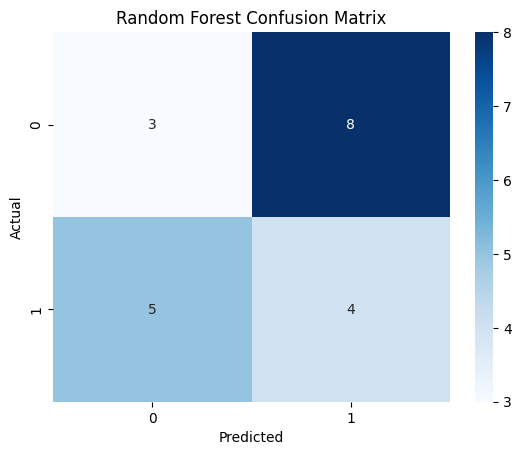

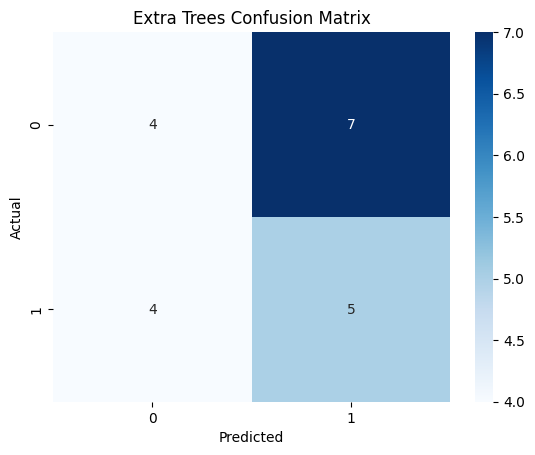

In [17]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(y_test, rf_preds, "Random Forest Confusion Matrix")
plot_conf_matrix(y_test, et_preds, "Extra Trees Confusion Matrix")

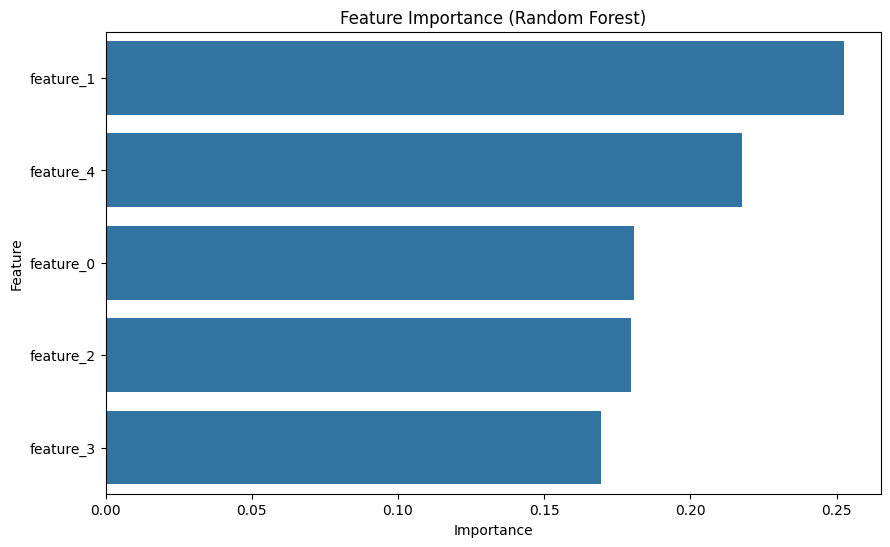

In [19]:
importances = rf_model.feature_importances_

# if X is numpy array:
feat_names = [f"feature_{i}" for i in range(X.shape[1])]

feat_df = pd.DataFrame({
    "Feature": feat_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance (Random Forest)")
plt.show()